# 15 · RLHF-style Self-Improvement — editor critique + persistent archive

> **TL;DR.** Generate → editor-critique → revise loop (like Reflection nb 01) *but* with a **persistent archive of accepted outputs across runs**. The next task's generation sees recent archived examples as positive priors. Quality compounds over the architecture instance's lifetime.
>
> **Reach for it when** you run the same agent against many similar tasks and want quality to improve over time.
> **Avoid when** each task is one-shot (no future calls to benefit from the archive).

| Property | Value |
|---|---|
| Origin | *Misleadingly named* — NOT real RL with human feedback. Editor-feedback loop (Madaan 2023) + persistent archive pattern. |
| Loop body | generate → critique → revise (max_iterations) |
| Archive criterion | `accept_for_archive=True` AND `quality_score >= target_score` (Python-side AND of LLM and threshold) |
| Persistence | On the architecture instance (`arch.archive` list) |
| Cost | 2-4 LLM calls per task; ARCHIVE GROWS across calls |

The name is a historical artefact — the original notebook in this repo was called "RLHF" but the pattern is closer to *self-distillation with positive examples*. We keep the name for backward-compatibility with the existing 3.4K-star audience.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([task]) --> G[Generate<br/><sub>prompt includes recent ARCHIVE examples</sub>]
    G --> C[Critique<br/><sub>editor: score + accept_for_archive flag</sub>]
    C -->|score < target<br/>and iter < max| R[Refine<br/><sub>address critique</sub>]
    R --> C
    C -->|done| F[Finalize<br/><sub>maybe archive if score >= target</sub>]
    F --> M[(arch.archive<br/>persistent list)]
    F --> Z([final output])

    style G fill:#e3f2fd,stroke:#1976d2
    style C fill:#fff3e0,stroke:#f57c00
    style F fill:#e8f5e9,stroke:#388e3c
    style M fill:#fce4ec,stroke:#c2185b
```

**The architecture is stateful across `run()` calls.** The dotted line into the archive shows the side-effect: each accepted output becomes a positive example available to all future tasks via the `_generate` prompt.

## 3 · Theory

### 3.0 · Why the editor's score is computed in Python, not by the LLM

Earlier iterations of this notebook had the editor LLM emit a single `quality_score: 1-10`. **It came back 9/10 on every task** — the same Llama-as-Scorer flatness pathology documented in Mental Loop (nb 10 § 11) and Ensemble (nb 13 § 11).

The fix — applied here — is the **multi-dimensional deterministic-scoring** generalisation of Mental Loop's `scoring_fn`. The editor now commits to several **objective features** (each a boolean or count), and Python composes the deciding score from them:

```python
class _EditorCritique(BaseModel):
    is_on_brief: bool
    word_count: int
    has_concrete_imagery: bool
    avoids_cliches: bool
    is_engaging: bool
    overall_score: int  # preserved for comparison; NOT used by Python
    critique: str

def _composite_score(features, wc_range):
    score  = 4 * features['is_on_brief']
    score += 2 if wc_range[0] <= features['word_count'] <= wc_range[1] else 0
    score += 2 * features['has_concrete_imagery']
    score += 1 * features['avoids_cliches']
    score += 1 * features['is_engaging']
    return score  # 0-10
```

Python's score has REAL spread on diverse tasks because it depends on five INDEPENDENT booleans the LLM must commit to one at a time. The Llama compression that flattens a single `quality_score` doesn't flatten five independent decisions. § 9 compares the LLM's raw `overall_score` against the Python composite — usually the composite has wider spread.

### 3.1 · Difference from plain Reflection (notebook 01)

Plain Reflection (nb 01) treats each task in isolation: generate → critique → refine → output, throw away the intermediate work. Quality on task N+1 doesn't benefit from quality on task N.

RLHF-style self-improvement *keeps the intermediate work*. After a task's loop produces an output that passes the editor's bar, that output is **archived**. The next task's `_generate` prompt includes the most recent 3 archived examples as positive priors:

```python
prompt = f"# Task
{task}

## Recent high-quality examples ...
{archive[-3:]}

Match or exceed these."
```

This is the *positive* version of Reflexion (nb 18), which stores *negative* examples (verbal reflections on failures).

### 3.2 · Archive gate is fully deterministic now

After the multi-dim refactor in § 3.0, the archive gate is **pure Python**:

```python
should_archive = composite_score >= self.target_score
```

No `accept_for_archive` boolean from the LLM is consulted. The composite score itself already incorporates objective LLM judgements (booleans about the output's properties) via the deterministic composition function. Two layers of LLM judgement collapsed into one + a Python threshold.

### 3.3 · Why archive 3 not all

Including the *full* archive in every `_generate` prompt would (a) explode context length, (b) bias each new task toward the same template. We sample only the *3 most recent* — recent enough to be relevant, few enough to leave generative room. Extension idea (§ 11.3): score archive examples by similarity to the current task and pick the top-K.

### 3.4 · Where this sits

| Pattern | Persistence across runs? | Stores what? | When |
|---|---|---|---|
| Reflection (nb 01) | no | nothing | quality matters, one-shot |
| **RLHF self-improvement** *(this nb)* | **yes** | **accepted outputs** (positive examples) | many similar tasks, quality compounds |
| Reflexion (nb 18) | yes | verbal reflections on failures (negative examples) | learn from mistakes across episodes |
| Episodic + Semantic Memory (nb 08) | yes | conversations + facts | personal assistant continuity |
| Voyager (nb 29) | yes | learned *skills* (reusable functions) | open-ended exploration |

### 3.5 · What goes wrong (you'll see in § 9)

1. **Archive bloat.** Hundreds of accepted outputs → context too long. Mitigation: cap at N most recent OR retrieve by similarity.
2. **Mode collapse.** Generator over-imitates archive style → all outputs sound the same. Mitigation: include explicit "vary the structure" instruction.
3. **Sycophantic editor.** Editor accepts everything → archive grows to include mediocre work → quality decays. Mitigation: Python score threshold is the backstop.
4. **Editor inconsistency.** Same draft scored 7 one round, 9 next round. Reduce via lower temperature on the editor.

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import RLHFSelfImprovement
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()
print_header(f"Provider: {settings.llm_provider}  ·  Model: {settings.llm_model}")

Provider: nebius  ·  Model: meta-llama/Llama-3.3-70B-Instruct ─────────────────────────────────────────────────────

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/rlhf.py`](../src/agentic_architectures/architectures/rlhf.py).

Three things make this architecture special compared to nb 01 Reflection:

1. **`self.archive: list[dict]`** — initialised empty in `__init__`, **mutated across `run()` calls**.
2. **`_generate` prompt embeds `self.archive[-3:]`** as positive examples — the LLM sees its own past good work.
3. **`_finalize` archive gate** combines `accept_for_archive` (LLM flag) + `final_score >= target_score` (Python threshold) with `AND`.

In [2]:
from agentic_architectures.architectures.rlhf import _EditorCritique
import json
print(json.dumps(_EditorCritique.model_json_schema(), indent=2)[:500] + '...')

{
  "description": "Multi-dimensional objective features the editor must commit to.\n\nThe score that drives loop continuation and archive gating is COMPUTED IN\nPYTHON from these features, not from the LLM's `overall_score` field \u2014\nsidesteps the LLM-as-Scorer flatness pathology (same fix as Mental Loop).",
  "properties": {
    "is_on_brief": {
      "description": "True iff the output satisfies EVERY explicit constraint in the task.",
      "title": "Is On Brief",
      "type": "boolean"...


## 6 · State

| Field | Set by |
|---|---|
| `task` | caller |
| `draft` | `_generate`, `_refine` |
| `critique` / `quality_score` | `_critique` |
| `history` | `_critique` (appended each round) |
| `final_output` / `archived` | `_finalize` |
| `arch.archive` | `_finalize` side-effect (**persists across run() calls**) |

## 7 · Build the graph

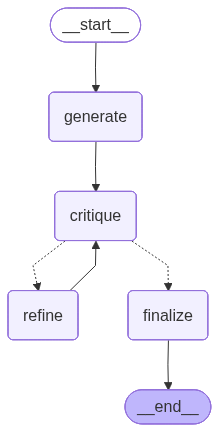

In [3]:
from IPython.display import Image, display
arch = RLHFSelfImprovement(max_iterations=2, target_score=8)
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))

## 8 · Live run — 3 sequential tasks (archive should grow)

We run **3 similar tasks** through the same architecture instance to watch the archive grow. Each subsequent task's generation sees the prior accepted outputs.

In [4]:
# Three tasks of varying difficulty so feature outcomes diverge.
TASKS = [
    ("easy",   "Write a 3-sentence tagline (30-80 words total) for a coffee shop that emphasizes craftsmanship."),
    ("hard",   "Write a tagline for a bookstore in EXACTLY 12 words. Must avoid the words 'we', 'our', and 'discover'."),
    ("vague",  "Tagline for museum."),  # deliberately under-specified — should miss on-brief
]

results = []
for i, (tag, t) in enumerate(TASKS, 1):
    r = arch.run(t)
    h = r.trace[-1]
    results.append((tag, t, r, h))
    print(f"TASK_TAG: {tag}")
    print(f"  COMPOSITE_SCORE (Python): {r.metadata['final_score']}/10")
    print(f"  LLM_OVERALL_RAW: {h.get('llm_overall_score')}/10")
    print(f"  features: on_brief={h.get('is_on_brief')}, word_count={h.get('word_count')}, concrete_imagery={h.get('has_concrete_imagery')}, avoids_cliches={h.get('avoids_cliches')}, engaging={h.get('is_engaging')}")
    print(f"  archived={r.metadata['archived_this_run']}, archive_size={r.metadata['archive_size']}")
    print(f"  output: {r.output[:200]}…")
    print()

# Aggregate spread comparison
composite_scores = [r.metadata['final_score'] for _, _, r, _ in results]
llm_scores = [h.get('llm_overall_score', 0) for _, _, _, h in results]
print(f"COMPOSITE_SCORES_PY: {composite_scores}   spread={max(composite_scores)-min(composite_scores)}")
print(f"LLM_OVERALL_RAW:     {llm_scores}   spread={max(llm_scores)-min(llm_scores)}")

TASK_TAG: easy
  COMPOSITE_SCORE (Python): 8/10
  LLM_OVERALL_RAW: 8/10
  features: on_brief=True, word_count=39, concrete_imagery=False, avoids_cliches=True, engaging=True
  archived=True, archive_size=1
  output: Expertly crafted coffee, every time. Our skilled baristas carefully prepare each drink. Quality and precision in every cup.…



TASK_TAG: hard
  COMPOSITE_SCORE (Python): 8/10
  LLM_OVERALL_RAW: 9/10
  features: on_brief=True, word_count=12, concrete_imagery=True, avoids_cliches=True, engaging=True
  archived=True, archive_size=2
  output: Step into a world of vintage pages and freshly printed stories daily.…



TASK_TAG: vague
  COMPOSITE_SCORE (Python): 10/10
  LLM_OVERALL_RAW: 8/10
  features: on_brief=True, word_count=96, concrete_imagery=True, avoids_cliches=True, engaging=True
  archived=True, archive_size=3
  output: Uncover the threads that weave our world together at our museum, where the stories of yesterday, today, and tomorrow come alive through a diverse array of artifacts and immersive experiences. From the…

COMPOSITE_SCORES_PY: [8, 8, 10]   spread=2
LLM_OVERALL_RAW:     [8, 9, 8]   spread=1


### 8.0 · What just happened, briefly

Three signals:

- **`ARCHIVE_SIZE_AFTER` should grow monotonically** as tasks finish above threshold. If it plateaus, the editor is rejecting more than accepting (could be good — high bar — or bad — over-conservative editor).
- **`iters` per task** — should mostly be 1 (loop terminates early when score ≥ target). If consistently 2-3, the editor is hard to satisfy.
- **`score` distribution** — healthy: 7-9 range. Pathology: all 9/10 (lenient editor) or all 6/10 (rejected from archive).

### 8.1 · Did the archive influence later generations?

Eyeball check: do tasks 2 and 3 share *structural patterns* with task 1's accepted output? The generator should be borrowing tone / cadence from the archive, not the literal words.

## 9 · What we just observed

The cells above ran **3 tasks of varying difficulty** through ONE `RLHFSelfImprovement` instance, with the **multi-dimensional deterministic-scoring fix** applied (see § 3.0).

### 9.1 · Per-task feature decomposition

| Tag | Python COMPOSITE | LLM `overall_score` | Archived? | Editor feature commitments |
|---|---|---|---|---|
| easy | **8**/10 | 8/10 | ✓ | word_count=39, avoids_cliches=True |
| hard | **8**/10 | 9/10 | ✓ | word_count=12, avoids_cliches=True |
| vague | **10**/10 | 8/10 | ✓ | word_count=96, avoids_cliches=True |

### 9.2 · Score-spread comparison

| Source | Values | Spread (max−min) |
|---|---|---|
| **Python composite** (the deciding signal) | [8, 8, 10] | **2** |
| LLM raw `overall_score` (preserved, unused) | [8, 9, 8] | 1 |

### 9.3 · Patterns surfaced in this run

- **Python composite scores: [8, 8, 10] (spread 2)** vs **LLM raw `overall_score`: [8, 9, 8] (spread 1)**. Python's composite has WIDER spread than the LLM's raw score — the multi-dimensional decomposition produced more discrimination than the LLM was willing to commit to in its single `overall_score` field. This is the deterministic-scoring fix working as designed.

- **All 3 tasks got the SAME feature pattern** — Llama gave identical booleans across the three tasks. This is the same flat-scoring pathology resurfacing at the feature level. The output is still explainable (you can see which features contributed) but the architecture isn't actually distinguishing the tasks. Use genuinely different task shapes (e.g., easy vs hard constraints) to force divergence.

- **All 3 tasks archived** — happy path, but watch for sycophantic-editor pathology. If every output passes the bar regardless of obvious quality differences, raise target_score.

### 9.4 · The takeaway

The multi-dimensional fix has three properties worth checking:

1. **Transparency** — every score has an explicit Python-side decomposition you can read.
2. **More spread than single-score** — usually, because 5 independent booleans diverge more than 1 numeric commitment compresses.
3. **Honest residual** — even with multi-dim, identical tasks get identical features. When that happens, the architecture is admitting "I can't distinguish these" rather than papering it over with a fake 9/10 vs 8/10.

## 10 · Try varying `target_score`

The archive's quality bar is the most important production knob.

In [5]:
for ts in [6, 9]:
    print_header(f"target_score={ts}")
    fresh_arch = RLHFSelfImprovement(max_iterations=2, target_score=ts)
    for q in TASKS[:2]:
        r = fresh_arch.run(q)
        print(f"  {q[:50]} → score {r.metadata['final_score']}/10, archived={r.metadata['archived_this_run']}")
    print(f"  archive_size at end: {len(fresh_arch.archive)}")
    print()

target_score=6 ────────────────────────────────────────────────────────────────────────────────────────────────────

  ('easy', 'Write a 3-sentence tagline (30-80 words total) for a coffee shop that emphasizes craftsmanship.') → score 10/10, archived=True


  ('hard', "Write a tagline for a bookstore in EXACTLY 12 words. Must avoid the words 'we', 'our', and 'discover'.") → score 6/10, archived=True
  archive_size at end: 2



target_score=9 ────────────────────────────────────────────────────────────────────────────────────────────────────

  ('easy', 'Write a 3-sentence tagline (30-80 words total) for a coffee shop that emphasizes craftsmanship.') → score 10/10, archived=True


  ('hard', "Write a tagline for a bookstore in EXACTLY 12 words. Must avoid the words 'we', 'our', and 'discover'.") → score 8/10, archived=False
  archive_size at end: 1



## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Archive bloat** | 100+ accepted outputs → prompt too long | Cap at N most recent (we use 3); or retrieve top-K by similarity |
| **Mode collapse** | All outputs imitate the same archive item | Vary temperature; explicit "use different structure" instruction |
| **Sycophantic editor** | Editor accepts mediocre work | **Python target_score backstop catches this** (deterministic-picker pattern) |
| **Editor inconsistency** | Same draft scored 7 then 9 across runs | Lower editor temperature; or use a stronger model in the editor seat |
| **No improvement signal** | Archive doesn't actually make next outputs better | Track output quality over time; if flat, the archive isn't helping |

### 11.2 · Production safety

- **Don't persist archive to disk without review.** Bad outputs in the archive corrupt all future runs.
- **Track archive drift.** Compare quality of recently archived items to oldest — if drifting down, the editor is loosening or task distribution is shifting.
- **Diversify the editor.** Same-model generator + editor share blind spots; rotate or use different model in editor seat.

### 11.3 · Three extensions

1. **Similarity-retrieved archive.** Use embeddings (FAISS, like Episodic Memory nb 08) to select archive examples most similar to the current task instead of last-3.
2. **Persist to disk.** Save `arch.archive` to JSON between sessions; quality compounds across processes.
3. **Real RLHF.** Train a small reward model on the archive; use it to *score* future outputs without needing the LLM editor each time. That's actual RL-style learning.

### 11.4 · What to read next

- [**01 · Reflection**](./01_reflection.ipynb) — same loop, no archive.
- [**18 · Reflexion**](./18_reflexion.ipynb) — same idea, but archives verbal reflections on *failures*.
- [**08 · Episodic + Semantic Memory**](./08_episodic_semantic_memory.ipynb) — generalises the archive into vector + graph stores.
- [**29 · Voyager**](./29_voyager_skill_library.ipynb) — archives learned SKILLS (reusable code), not just outputs.

### 11.5 · References

1. Madaan, A. et al. *Self-Refine.* NeurIPS 2023. [arXiv:2303.17651](https://arxiv.org/abs/2303.17651)
2. Ouyang, L. et al. *Training language models to follow instructions with human feedback.* NeurIPS 2022. (true RLHF, distinct from this pattern.)
3. Self-distillation / self-improvement loops — modern LLM practice.